# House Prices: базова модель регресії

**Автор:** Єлизавета Перькова

**Мета:** після аналізу та візуалізації даних (Lab02, Lab03) зробити наступний крок — навчити першу модель, що прогнозує ціну будинку, і чесно оцінити її якість на даних, яких модель не бачила.

**План:**
1. Підготувати дані тим самим пайплайном, що й у Lab02/Lab03.
2. Порівняти найпростішу модель (завжди прогнозує середню ціну) з лінійною регресією.
3. Перевірити стабільність результату крос-валідацією і розібрати причину нестабільності.
4. Обробити викиди, прологарифмувати ціну, додати регуляризацію (Ridge).
5. Оцінити фінальну модель на відкладеній тестовій вибірці.

**Метрики:** RMSE у доларах (середня помилка прогнозу), R² (частка поясненої дисперсії) та RMSLE (помилка в логарифмічній шкалі, яка менш чутлива до дорогих будинків).

## 1. Підготовка даних

Пайплайн очищення такий самий, як у Lab03: видалення колонок із надмірними пропусками, заповнення пропусків, нові ознаки `HouseAge`, `TotalSF`, `RemodAge`, перейменування.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

df = pd.read_csv("house_prices.csv")

df_clean = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"])

neighborhood_median = df_clean.groupby("Neighborhood")["LotFrontage"].median()
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["Neighborhood"].map(neighborhood_median))
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())
df_clean["MasVnrType"] = df_clean["MasVnrType"].fillna("None")
df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)

none_cols = ["FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for c in none_cols:
    df_clean[c] = df_clean[c].fillna("None")
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(0)
df_clean["Electrical"] = df_clean["Electrical"].fillna(df_clean["Electrical"].mode()[0])

df_clean["MSSubClass"] = df_clean["MSSubClass"].astype(str)
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].astype(int)

df_clean["HouseAge"] = df_clean["YrSold"] - df_clean["YearBuilt"]
df_clean["TotalSF"] = df_clean["TotalBsmtSF"] + df_clean["1stFlrSF"] + df_clean["2ndFlrSF"]
df_clean["RemodAge"] = df_clean["YrSold"] - df_clean["YearRemodAdd"]

df_clean = df_clean.rename(columns={"GrLivArea": "LivingAreaAboveGround", "SalePrice": "Price"})
df_clean = df_clean.drop(columns=["Id"])

print(f"Рядків: {df_clean.shape[0]}, колонок: {df_clean.shape[1]}, пропусків: {df_clean.isna().sum().sum()}")

Рядків: 1460, колонок: 79, пропусків: 0


## 2. Ознаки та попередня обробка для моделі

Цільова змінна — `Price`. Числові ознаки масштабую (`StandardScaler`), категоріальні кодую one-hot (`OneHotEncoder`). Усе це в одному `Pipeline`, щоб масштабування й кодування вчились **лише на тренувальних даних** і не було витоку інформації з тесту.

In [2]:
X = df_clean.drop(columns="Price")
y = df_clean["Price"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f"Числових ознак: {len(num_cols)}, категоріальних: {len(cat_cols)}")

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

def make_model(estimator, log_target=False):
    # log_target=True: модель вчиться на log(1 + ціна), прогноз повертається у доларах
    if log_target:
        estimator = TransformedTargetRegressor(estimator, func=np.log1p, inverse_func=np.expm1)
    return Pipeline([("prep", make_preprocessor()), ("model", estimator)])

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def rmsle(y_true, y_pred):
    return rmse(np.log1p(y_true), np.log1p(np.clip(y_pred, 1, None)))

def report(name, y_true, y_pred):
    return {"Модель": name, "RMSE, $": round(rmse(y_true, y_pred)),
            "R²": round(r2_score(y_true, y_pred), 3), "RMSLE": round(rmsle(y_true, y_pred), 3)}

Числових ознак: 38, категоріальних: 40


## 3. Перший baseline

Розбиваю дані 80/20. **Baseline** — модель, яка завжди прогнозує середню ціну з тренувальної вибірки: будь-яка корисна модель має бути помітно кращою за неї. Порівнюю з лінійною регресією на всіх ознаках.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

rows = []
for name, model in [
    ("Середня ціна (baseline)", make_model(DummyRegressor(strategy="mean"))),
    ("Лінійна регресія", make_model(LinearRegression())),
]:
    model.fit(X_train, y_train)
    rows.append(report(name, y_test, model.predict(X_test)))

pd.DataFrame(rows)

,Модель,"RMSE, $",R²,RMSLE
0,Середня ціна (baseline),87619,-0.001,0.446
1,Лінійна регресія,29635,0.886,0.178


## 4. Перевірка стабільності: крос-валідація

Один розподіл на train/test може дати випадково гарний або поганий результат. Перевіряю лінійну регресію 5-кратною крос-валідацією: якщо модель стабільна, помилка на всіх частинах має бути схожою.

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_rmse, worst = [], []
for i, (tr, te) in enumerate(kf.split(X)):
    m = make_model(LinearRegression()).fit(X.iloc[tr], y.iloc[tr])
    pred = m.predict(X.iloc[te])
    fold_rmse.append(rmse(y.iloc[te], pred))
    errors = np.abs(pred - y.iloc[te].values)
    j = errors.argmax()
    worst.append((X.iloc[te].index[j], y.iloc[te].values[j], pred[j], X.iloc[te]["LivingAreaAboveGround"].values[j]))

print("RMSE по частинах:", [round(v) for v in fold_rmse])
bad = int(np.argmax(fold_rmse))
idx, true_price, pred_price, area = worst[bad]
print(f"\nНайгірша частина №{bad + 1}. Найбільша помилка у будинку з індексом {idx}:")
print(f"  житлова площа {area} кв. футів, реальна ціна ${true_price:,.0f}, прогноз ${pred_price:,.0f}")

RMSE по частинах: [29635, 26911, 56387, 35455, 23885]

Найгірша частина №3. Найбільша помилка у будинку з індексом 1298:
  житлова площа 5642 кв. футів, реальна ціна $160,000, прогноз $921,191


Одна з частин має помітно більшу помилку, і причина — один будинок: дуже велика площа, але низька ціна. Це ті самі «дивні точки праворуч внизу», які я помітила на Графіку 2 у Lab03. Лінійна модель екстраполює «більша площа — вища ціна» і дає абсурдний прогноз для такого об'єкта.

Подивлюсь на ці точки.

      LivingAreaAboveGround   Price Neighborhood SaleCondition
523                    4676  184750      Edwards       Partial
1298                   5642  160000      Edwards       Partial


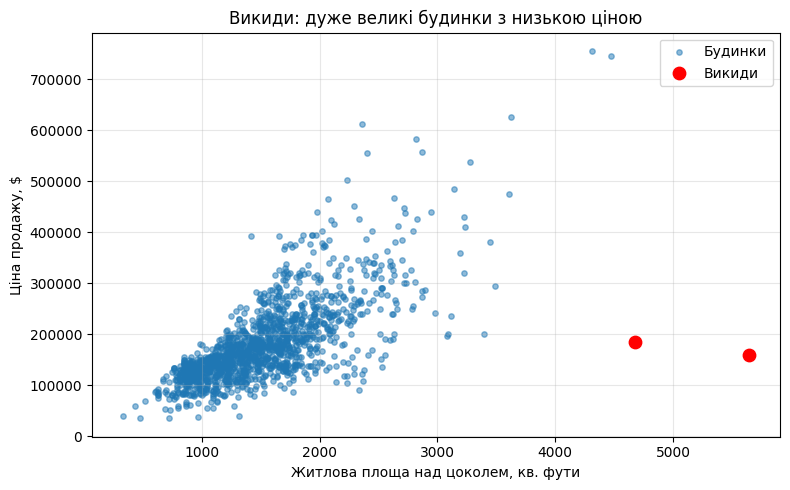

In [5]:
outlier_mask = (df_clean["LivingAreaAboveGround"] > 4000) & (df_clean["Price"] < 300_000)
print(df_clean.loc[outlier_mask, ["LivingAreaAboveGround", "Price", "Neighborhood", "SaleCondition"]])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean["LivingAreaAboveGround"], df_clean["Price"], s=15, alpha=0.5, label="Будинки")
ax.scatter(df_clean.loc[outlier_mask, "LivingAreaAboveGround"], df_clean.loc[outlier_mask, "Price"],
           s=80, color="red", label="Викиди")
ax.set_xlabel("Житлова площа над цоколем, кв. фути")
ax.set_ylabel("Ціна продажу, $")
ax.set_title("Викиди: дуже великі будинки з низькою ціною")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Обробка викидів

Два будинки площею понад 4000 кв. футів продані за ціною нижче $300K — вони не відповідають загальній закономірності (це видно і на графіку). Для таких об'єктів модель не буде надійною, тому я видаляю їх із датасету. Це свідоме обмеження: модель не призначена для надвеликих будинків із нетиповою ціною.

Далі: перший розподіл на train/test (з викидами) відкидаю і роблю новий — вже на очищених даних.

In [6]:
df_model = df_clean[~outlier_mask]
X = df_model.drop(columns="Price")
y = df_model["Price"]
print(f"Лишилось будинків: {len(df_model)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}, test: {len(X_test)}")

Лишилось будинків: 1458
Train: 1166, test: 292


## 6. Логарифм ціни та регуляризація

- **Логарифм ціни.** Розподіл ціни скошений вправо (Графік 1 у Lab03), а помилка в доларах сильно залежить від дорогих будинків. Навчання на `log(1 + ціна)` вирівнює розподіл.
- **Ridge-регресія.** У Lab03 я бачила, що `TotalSF` і житлова площа сильно корельовані (мультиколінеарність). Ridge штрафує великі коефіцієнти й робить модель стійкішою до такої кореляції. Силу штрафу `alpha` обираю крос-валідацією **лише на тренувальних даних**, щоб не підглядати в тест.

In [7]:
candidates = [
    ("Лінійна, ціна в $", LinearRegression(), False),
    ("Лінійна, log(ціни)", LinearRegression(), True),
] + [(f"Ridge, log(ціни), alpha={a}", Ridge(alpha=a), True) for a in [1, 3, 10, 30]]

rows = []
for name, est, log_target in candidates:
    scores = -cross_val_score(make_model(est, log_target), X_train, y_train, cv=kf,
                              scoring="neg_root_mean_squared_error")
    rows.append({"Модель": name, "RMSE (середнє по 5 частинах), $": round(scores.mean()),
                 "Розкид (std), $": round(scores.std())})

cv_table = pd.DataFrame(rows)
cv_table

,Модель,"RMSE (середнє по 5 частинах), $","Розкид (std), $"
0,"Лінійна, ціна в $",26834,1856
1,"Лінійна, log(ціни)",22305,2148
2,"Ridge, log(ціни), alpha=1",20752,1780
3,"Ridge, log(ціни), alpha=3",20238,1892
4,"Ridge, log(ціни), alpha=10",19980,2001
5,"Ridge, log(ціни), alpha=30",20168,2172


In [8]:
alphas = [1, 3, 10, 30]
ridge_scores = cv_table.iloc[2:]["RMSE (середнє по 5 частинах), $"].tolist()
best_alpha = alphas[int(np.argmin(ridge_scores))]
print(f"Найкраща alpha за крос-валідацією: {best_alpha}")

Найкраща alpha за крос-валідацією: 10


## 7. Фінальна оцінка на тестовій вибірці

Тестову вибірку модель ще не бачила: ні для навчання, ні для вибору `alpha`.

In [9]:
final_models = [
    ("Середня ціна (baseline)", make_model(DummyRegressor(strategy="mean"))),
    ("Лінійна, ціна в $", make_model(LinearRegression())),
    ("Лінійна, log(ціни)", make_model(LinearRegression(), log_target=True)),
    (f"Ridge, log(ціни), alpha={best_alpha}", make_model(Ridge(alpha=best_alpha), log_target=True)),
]

rows, preds = [], {}
for name, model in final_models:
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)
    rows.append(report(name, y_test, preds[name]))

results = pd.DataFrame(rows)
results

,Модель,"RMSE, $",R²,RMSLE
0,Середня ціна (baseline),74324,-0.000,0.418
1,"Лінійна, ціна в $",26228,0.875,0.281
2,"Лінійна, log(ціни)",21668,0.915,0.135
3,"Ridge, log(ціни), alpha=10",19865,0.929,0.122


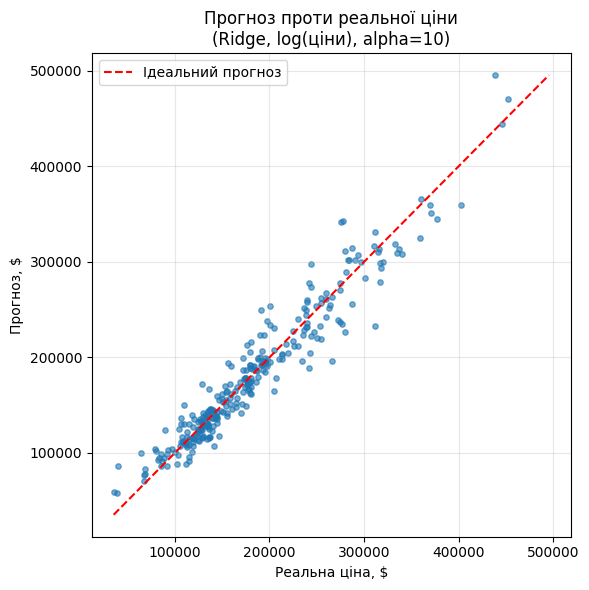

In [10]:
best_final = final_models[-1][0]
y_pred = preds[best_final]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=15, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Ідеальний прогноз")
ax.set_xlabel("Реальна ціна, $")
ax.set_ylabel("Прогноз, $")
ax.set_title(f"Прогноз проти реальної ціни\n({best_final})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Висновки та обмеження

**Висновки**
- Найпростіший baseline (середня ціна) дає помилку близько $74K і R² ≈ 0. Лінійна регресія на підготовлених ознаках значно краща, що підтверджує: ознаки, які я виділила в аналізі (якість, площа, район), справді несуть інформацію про ціну.
- **Видалення двох викидів**, які я помітила ще на візуалізації, зробило модель стабільною: до цього в одній з частин крос-валідації помилка зростала до $56K проти $24–35K в інших, а після — розкид між частинами складає близько $2K. **Логарифм ціни** знизив RMSE лінійної регресії приблизно з $26K до $22K на тесті.
- Ridge із `alpha`, обраною крос-валідацією, трохи покращив результат порівняно зі звичайною лінійною регресією, що узгоджується з наявною мультиколінеарністю між `TotalSF` і житловою площею.

**Обмеження**
- Медіана `LotFrontage` по районах рахувалась на всьому датасеті до розбиття, тобто є невеликий витік інформації з тесту. У наступній версії це варто винести в `Pipeline`.
- Один розподіл train/test і лише лінійні моделі. Не перевірені дерева рішень і ансамблі, які зазвичай краще працюють із такими даними.
- Модель не призначена для дуже великих будинків із нетиповою ціною (їх я видалила як викиди).
- Не досліджувала, які саме ознаки вносять найбільший внесок у прогноз (інтерпретація моделі) — це наступний крок.